In [24]:
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns

In [71]:
df = pd.read_csv("../DATA/Anthocyanin_with_rgb_051225-050226.csv")

df['DATE'] = pd.to_datetime(df['DATE'],format='%d/%m/%Y')
df['DATE'] = df['DATE'].dt.date
df.sort_values(by="DATE", inplace=True)
df.head(1)

,label_name,bbox_x,bbox_y,bbox_width,bbox_height,image_name,image_width,image_height,huePlantMean,satPlantMean,...,category,Lettuce color,Leaf sample weight (mg),Sample disc weight (g),Anthocyanin_OD_530_nm,Chlorophyll OD-657 nm,Chlorophyll interference,Anthocyanin,DATE,Illumination
268,C5,1708,184,1527,1329,20251203_130452.jpg,4000,1800,0.095094,0.247385,...,RED_Control_ids,RED,0.21,0.03,1.5604,0.1099,0.027,1.533,2025-12-05,Control-Sun


In [72]:
df[['Anthocyanin', 'Anthocyanin_OD_530_nm']].corr()

,Anthocyanin,Anthocyanin_OD_530_nm
Anthocyanin,1.000000,0.982578
Anthocyanin_OD_530_nm,0.982578,1.000000


In [73]:
df.columns

Index(['label_name', 'bbox_x', 'bbox_y', 'bbox_width', 'bbox_height',
       'image_name', 'image_width', 'image_height', 'huePlantMean',
       'satPlantMean', 'valPlantMean', 'huePlantStd', 'satPlantStd',
       'valPlantStd', 'huePlantMedian', 'satPlantMedian', 'valPlantMedian',
       'category', 'Lettuce color', 'Leaf sample weight (mg)',
       'Sample disc weight (g)', 'Anthocyanin_OD_530_nm',
       'Chlorophyll OD-657 nm', 'Chlorophyll interference', 'Anthocyanin',
       'DATE', 'Illumination'],
      dtype='str')

In [74]:
target= 'Anthocyanin' #'Anthocyanin_OD_530_nm'
df_red=df[df['Lettuce color'] == 'RED']
df_green=df[df['Lettuce color'] == 'GREEN']

Target column: Anthocyanin
Data type: float64
Number of values: 270
Number of non-null values: 270
Min/Max values: -0.111/1.576


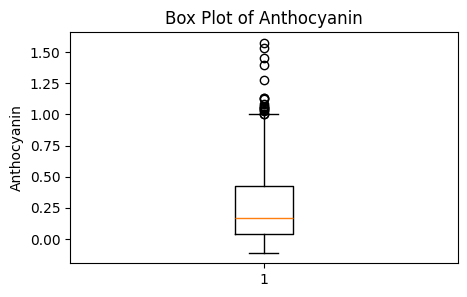

In [75]:
# Check the data first
print(f"Target column: {target}")
print(f"Data type: {df[target].dtype}")
print(f"Number of values: {len(df[target])}")
print(f"Number of non-null values: {df[target].notna().sum()}")
print(f"Min/Max values: {df[target].min()}/{df[target].max()}")

# Create the box plot properly
fig = plt.figure(figsize=(5, 3))
# Remove NaN values before plotting
clean_data = df[target].dropna()
plt.boxplot(clean_data)
plt.title(f'Box Plot of {target}')
plt.ylabel(target)
plt.show()

In [76]:
def find_outliers_iqr(data):
    Q1 = data.quantile(0.25)
    Q3 = data.quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    # Return the outlier values
    return data[(data < lower_bound) | (data > upper_bound)]

# Example usage:
outliers_list = find_outliers_iqr(df[target])
sorted(outliers_list) 

# 1. Identify the outliers in your target column
outliers = find_outliers_iqr(df[target])

# 2. Filter the DataFrame to keep only rows NOT in the outlier list
# The '~' symbol means "NOT"
df_clean = df[~df.index.isin(outliers.index)]

# Optional: Print the results to verify
print(f"Original rows: {len(df)}")
print(f"Outliers removed: {len(outliers)}")
print(f"Final rows: {len(df_clean)}")

#df_clean.to_csv("../DATA/Anthocyanin_with_rgb_051225-311225_clean.csv", index=False)


Original rows: 270
Outliers removed: 18
Final rows: 252


In [ ]:
sorted(outliers) # 

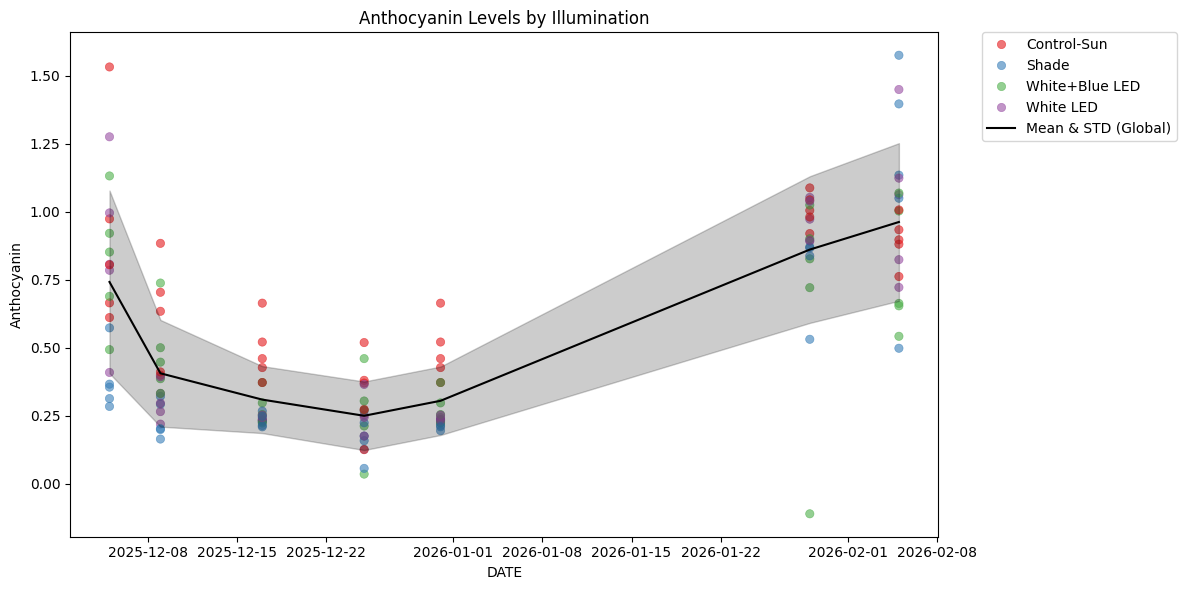

In [78]:


# 1. Create the figure
plt.figure(figsize=(12, 6))

# 2. Draw the Scatter Plot with Seaborn
# 'hue' handles the colors and creates the legend automatically
sns.scatterplot(
    data=df_red, 
    x='DATE', 
    y=target, 
    hue='Illumination', 
    palette='Set1', 
    alpha=0.6,
    edgecolor=None
)

# 3. Draw the Mean + STD line on top
sns.lineplot(
    data=df_red, 
    x='DATE', 
    y=target, 
    color='black', 
    errorbar='sd', 
    label='Mean & STD (Global)'
)

# 4. Move the legend so it doesn't cover the data
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)

plt.title(f'{target} Levels by Illumination')
plt.tight_layout() # Prevents the legend from being cut off
plt.show()

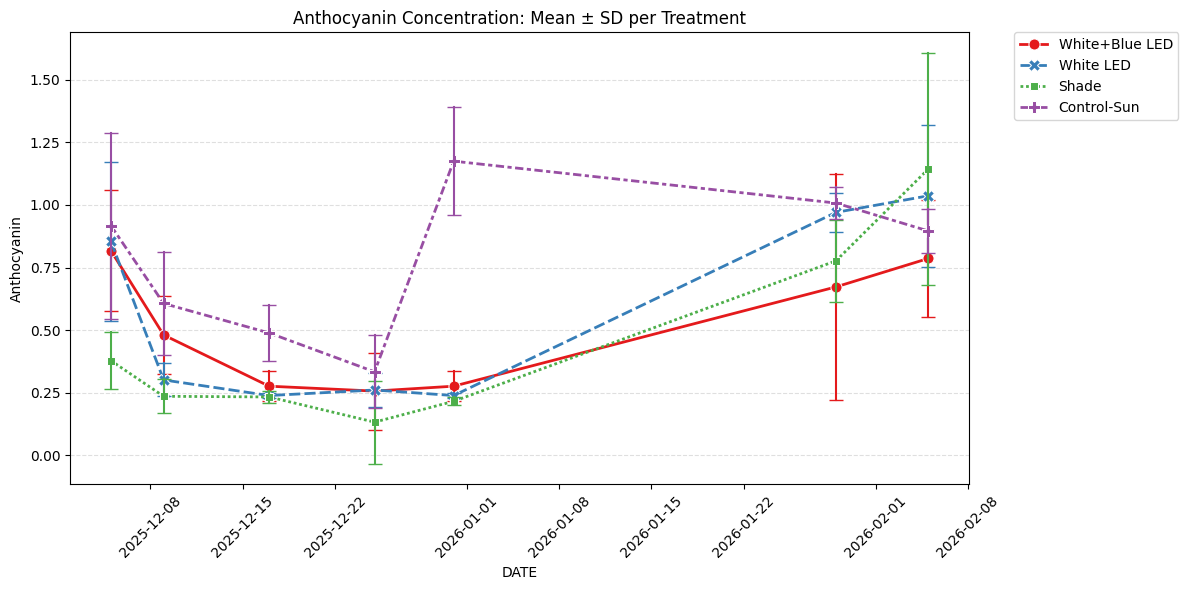

In [17]:


plt.figure(figsize=(12, 6))

# Use err_kws to pass capsize to the underlying errorbar function
sns.lineplot(
    data=df_red, 
    x='DATE', 
    y=target, 
    hue='Illumination', 
    style='Illumination',
    markers=True,         
    errorbar='sd',        
    err_style='bars',     
    err_kws={'capsize': 5},  # This is the fix!
    palette='Set1',
    linewidth=2,
    markersize=8
)

plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)
plt.title(f'{target} Concentration: Mean ± SD per Treatment')
plt.ylabel(f'{target}')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

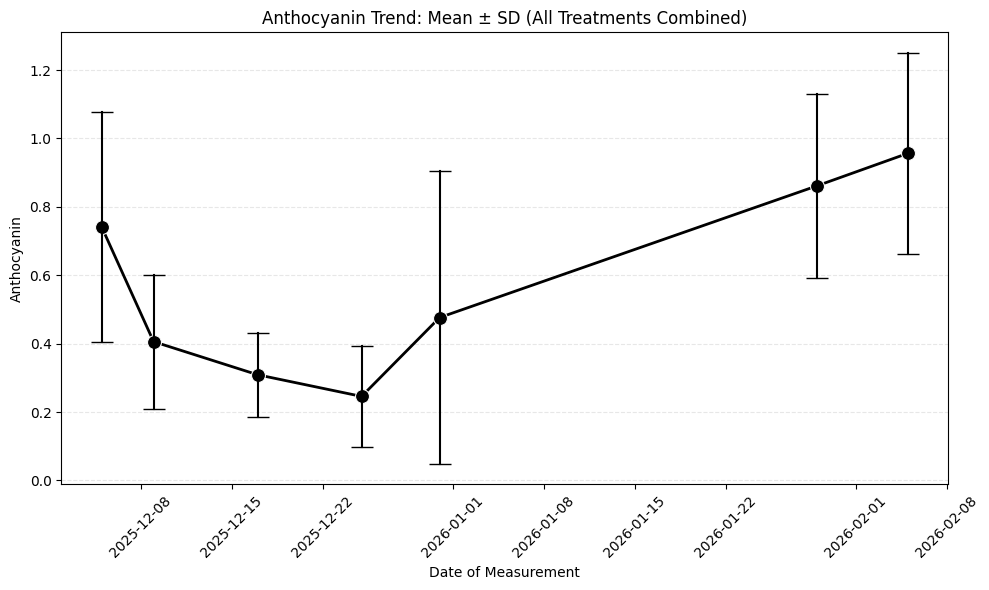

In [18]:


# 1. Create the figure
plt.figure(figsize=(10, 6))

# 2. Draw the Global Error Bar Plot
# By removing 'hue', we force Seaborn to aggregate ALL treatments together
sns.lineplot(
    data=df_red, 
    x='DATE', 
    y=target, 
    marker='o',           # Adds a single dot for the global mean
    errorbar='sd',        # Calculates the SD of all samples on that date
    err_style='bars',     # Shows the "I" bars
    err_kws={'capsize': 8}, 
    color='black',        # A neutral color for global data
    linewidth=2,
    markersize=10
)

# 3. Formatting
plt.title(f'{target} Trend: Mean ± SD (All Treatments Combined)')
plt.ylabel(f'{target}')
plt.xlabel('Date of Measurement')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

In [19]:
# 1. Group by DATE
# 2. Pick the column target
# 3. Aggregate by 'mean' and 'std'
stats_df = df_red.groupby('DATE')[target].agg(['mean', 'std']).reset_index()

# Display the result
print(stats_df)

         DATE      mean       std
0  2025-12-05  0.741950  0.336214
1  2025-12-09  0.405900  0.196255
2  2025-12-17  0.309100  0.123152
3  2025-12-25  0.245750  0.147413
4  2025-12-31  0.476300  0.427102
5  2026-01-29  0.861053  0.269819
6  2026-02-05  0.956263  0.294012


In [20]:
# Group by two columns instead of one
detailed_stats = df_red.groupby(['DATE', 'Illumination'])[target].agg(['mean', 'std']).reset_index()

# This gives you a row for every unique Date-Illumination combination
# Sort by Illumination alphabetically
detailed_stats = detailed_stats.sort_values(by=['Illumination','DATE' ])

# Display the sorted result
print(detailed_stats)

          DATE    Illumination     mean       std
0   2025-12-05     Control-Sun  0.91760  0.371614
4   2025-12-09     Control-Sun  0.60640  0.205271
8   2025-12-17     Control-Sun  0.48880  0.111829
12  2025-12-25     Control-Sun  0.33340  0.145806
16  2025-12-31     Control-Sun  1.17500  0.215678
20  2026-01-29     Control-Sun  1.00760  0.063595
24  2026-02-05     Control-Sun  0.89620  0.089368
1   2025-12-05           Shade  0.37820  0.113753
5   2025-12-09           Shade  0.23560  0.067211
9   2025-12-17           Shade  0.23300  0.024259
13  2025-12-25           Shade  0.13240  0.165784
17  2025-12-31           Shade  0.21560  0.015469
21  2026-01-29           Shade  0.77675  0.164492
25  2026-02-05           Shade  1.14350  0.464115
2   2025-12-05       White LED  0.85460  0.317506
6   2025-12-09       White LED  0.30100  0.066087
10  2025-12-17       White LED  0.23860  0.008989
14  2025-12-25       White LED  0.26080  0.068247
18  2025-12-31       White LED  0.23860  0.008989


c:\myProjects\phenomobile\.venv\Lib\site-packages\pandas\plotting\_matplotlib\core.py:1388: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  scatter = ax.scatter(


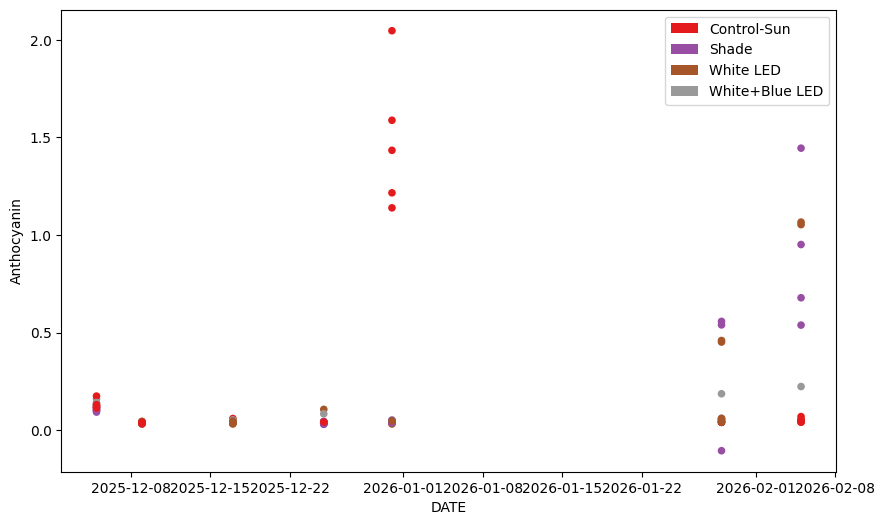

In [21]:
df_green=df[df['Lettuce color'] == 'GREEN']


df_green.plot.scatter(x='DATE', y=target, 
        c='Illumination', 
        colormap='Set1',figsize=(10, 6) ,
        sharex=False)          

plt.show()